# Temporal Prediction Target Attribution Analysis

Fast analysis focused on **temporal prediction targets** (`case_elapsed_time` and `event_elapsed_time`).

**Performance Optimizations:**
- Reduced IG steps (default: 20)
- Optional: Skip IG and only compute prediction quality metrics
- Sample-based analysis for large datasets
- Progress saved incrementally

In [1]:
import importlib
import sys
import torch
import torch.nn.functional as F
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')

from aa_philipp.model_with_integrated_gradients.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from aa_philipp.model_with_integrated_gradients.dropout_uncertainty_decoder_forward_simplified import PSP_Model_simplified
from aa_philipp.model_with_integrated_gradients.embedder import get_final_process_step
from captum.attr import IntegratedGradients

import evaluation.evaluation
importlib.reload(evaluation.evaluation)
from evaluation.evaluation import Evaluation

In [2]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

## Configuration

In [3]:
# ============================================================
# PERFORMANCE SETTINGS
# ============================================================

# Set to False for FAST mode (skip IG, only compute prediction quality)
# Set to True for FULL mode (includes IG attributions - slower)
COMPUTE_ATTRIBUTIONS = True

# Number of cases to analyze (set low for quick testing)
MAX_CASES = 50  # Set to None for all cases

# IG steps - lower = faster (20 is usually sufficient)
IG_STEPS = 20

# Sample every Nth prefix (1 = all, 2 = every other, etc.)
SAMPLE_RATE = 1

# ============================================================
# ANALYSIS SETTINGS
# ============================================================

# Which temporal target: "case_elapsed_time", "event_elapsed_time", or "both"
TEMPORAL_TARGET = "both"

# Top-K best/worst to show
TOP_K = 5

# ============================================================
# PATHS
# ============================================================

MODEL_PATH = '../../notebooks/training_variational_dropout/Helpdesk/Helpdesk_full_grad_norm_philipp_4layer.pkl'
DATASET_PATH = '../../../encoded_data/test_philipp/helpdesk_all_5_test.pkl'

print(f"Mode: {'FULL (with IG)' if COMPUTE_ATTRIBUTIONS else 'FAST (predictions only)'}")
print(f"Max cases: {MAX_CASES}")
print(f"IG steps: {IG_STEPS}")
print(f"Sample rate: 1/{SAMPLE_RATE}")

Mode: FULL (with IG)
Max cases: 50
IG steps: 20
Sample rate: 1/1


## Load Model and Data

In [4]:
model = DropoutUncertaintyEncoderDecoderLSTM.load(MODEL_PATH, dropout=0.0)
dataset = torch.load(DATASET_PATH, weights_only=False)
print(f"Model and dataset loaded.")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

Model and dataset loaded.


In [5]:
eval_helper = Evaluation(
    model=model, 
    dataset=dataset,
    concept_name='Activity',
    growing_num_values=['case_elapsed_time'],
    all_cat=['Activity', 'Resource'],
    all_num=['case_elapsed_time', 'event_elapsed_time']
)

cases = eval_helper._get_cases_from_dataset()
case_items = list(eval_helper.cases.items())

if MAX_CASES:
    case_items = case_items[:MAX_CASES]

print(f"Cases to process: {len(case_items)}")

Cases to process: 50


## Core Functions

In [6]:
# Simplified model for forward pass
_simplified_model = None

def get_simplified_model():
    global _simplified_model
    if _simplified_model is None:
        _simplified_model = PSP_Model_simplified(model=model)
    return _simplified_model


def fast_forward(prefix):
    """Fast forward pass without gradient tracking."""
    with torch.no_grad():
        prefixes_embedded = model.encoder.data_enc_for_model(data=prefix)
        cat_prefixes, num_prefixes = prefix
        cat_sos = [c[:, -1:] for c in cat_prefixes]
        num_sos = [n[:, -1:] for n in num_prefixes]
        sos_embedded = model.decoder.data_enc_for_model(data=[cat_sos, num_sos], pred=False)
        return get_simplified_model().forward(prefix=(prefixes_embedded, sos_embedded))


def compute_temporal_metrics(predictions, suffix, eval_helper, time_key):
    """Compute temporal prediction quality metrics."""
    pred_mean = predictions[0][1][f"{time_key}_mean"][0][0].item()
    pred_log_var = predictions[1][1][f"{time_key}_var"][0][0].item()
    pred_var = np.exp(pred_log_var)
    pred_std = np.sqrt(pred_var)
    confidence = 1.0 / (1.0 + pred_var)
    
    if suffix is None:
        return {'pred_mean': pred_mean, 'pred_std': pred_std, 'confidence': confidence,
                'true_value': None, 'mae': None, 'error': None}
    
    time_idx = eval_helper.all_num_attributes.index(time_key)
    true_vals = suffix[1][time_idx][0].numpy()
    mask = true_vals != 0
    true_value = true_vals[mask][0] if mask.any() else true_vals[0]
    
    error = pred_mean - true_value
    return {
        'pred_mean': pred_mean,
        'pred_std': pred_std,
        'pred_var': pred_var,
        'confidence': confidence,
        'true_value': true_value,
        'mae': abs(error),
        'error': error
    }

In [7]:
# IG functions (only used if COMPUTE_ATTRIBUTIONS=True)

def forward_for_ig(prefix, target_fn):
    preds = get_simplified_model().forward(prefix=prefix)
    return target_fn(preds)


def compute_ig(prefix, time_key, n_steps=20):
    """Compute Integrated Gradients for temporal target."""
    prefixes_embedded = model.encoder.data_enc_for_model(data=prefix).detach().requires_grad_(True)
    sos_event = get_final_process_step(prefix)
    sos_embedded = model.decoder.data_enc_for_model(data=sos_event, pred=False).detach().requires_grad_(True)
    
    target_fn = lambda p: p[0][1][f"{time_key}_mean"][0][0].unsqueeze(0)
    
    ig = IntegratedGradients(lambda x1, x2: forward_for_ig((x1, x2), target_fn))
    
    attrs, _ = ig.attribute(
        inputs=(prefixes_embedded, sos_embedded),
        baselines=(torch.zeros_like(prefixes_embedded), torch.zeros_like(sos_embedded)),
        n_steps=n_steps,
        return_convergence_delta=True
    )
    
    # Combine attributions
    prefix_len = prefixes_embedded.shape[0]
    attrs[0][prefix_len - 1, :, :attrs[1].shape[-1]] += attrs[1][0]
    return attrs[0]


def unpack_attrs(attr_tensor, prefix_len, eval_helper):
    """Unpack embedding attributions to feature-level."""
    result = defaultdict(float)
    
    for t in range(-prefix_len, 0):
        sample = attr_tensor[t, 0, :]
        idx = 0
        for i, attr_name in enumerate(eval_helper.prefix_cat_attributes):
            dim = eval_helper.model.encoder.embeddings[i].embedding_dim
            result[attr_name] += sample[idx:idx+dim].mean().detach().item()
            idx += dim
    
    # Average over timesteps
    return {k: v / prefix_len for k, v in result.items()}

## Run Analysis

In [8]:
def run_analysis(time_key):
    """Run temporal analysis for a single time target."""
    results = []
    prefix_count = 0
    
    for case_name, full_case in tqdm(case_items, desc=f"{time_key}"):
        for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
            prefix_count += 1
            if prefix_count % SAMPLE_RATE != 0:
                continue
            
            try:
                preds = fast_forward(prefix)
                metrics = compute_temporal_metrics(preds, suffix, eval_helper, time_key)
                
                row = {
                    'case_name': case_name,
                    'prefix_len': prefix_len,
                    **metrics
                }
                
                if COMPUTE_ATTRIBUTIONS:
                    attrs = compute_ig(prefix, time_key, n_steps=IG_STEPS)
                    row['attributions'] = unpack_attrs(attrs, prefix_len, eval_helper)
                
                results.append(row)
                
            except Exception as e:
                continue
    
    return pd.DataFrame(results)


# Run for selected targets
results = {}

if TEMPORAL_TARGET in ["case_elapsed_time", "both"]:
    results['case_elapsed_time'] = run_analysis('case_elapsed_time')
    print(f"\ncase_elapsed_time: {len(results['case_elapsed_time'])} samples")
    print(f"  Mean MAE: {results['case_elapsed_time']['mae'].mean():.4f}")

if TEMPORAL_TARGET in ["event_elapsed_time", "both"]:
    results['event_elapsed_time'] = run_analysis('event_elapsed_time')
    print(f"\nevent_elapsed_time: {len(results['event_elapsed_time'])} samples")
    print(f"  Mean MAE: {results['event_elapsed_time']['mae'].mean():.4f}")

case_elapsed_time:   0%|          | 0/50 [00:00<?, ?it/s]


case_elapsed_time: 185 samples
  Mean MAE: 0.7558


event_elapsed_time:   0%|          | 0/50 [00:00<?, ?it/s]


event_elapsed_time: 185 samples
  Mean MAE: 0.9646


## Best/Worst Analysis

In [9]:
def show_best_worst(df, time_key, top_k=5):
    """Display best and worst predictions."""
    valid = df[df['mae'].notna()].copy()
    sorted_df = valid.sort_values('mae')
    
    print(f"\n{'='*60}")
    print(f"{time_key.upper()}")
    print(f"{'='*60}")
    
    print(f"\n--- BEST {top_k} (Lowest MAE) ---")
    for i, (_, row) in enumerate(sorted_df.head(top_k).iterrows()):
        print(f"  [{i+1}] {row['case_name']} (prefix={row['prefix_len']}): "
              f"pred={row['pred_mean']:.3f}, true={row['true_value']:.3f}, MAE={row['mae']:.4f}")
        if COMPUTE_ATTRIBUTIONS and 'attributions' in row:
            top_attrs = sorted(row['attributions'].items(), key=lambda x: abs(x[1]), reverse=True)[:3]
            print(f"      Top attrs: {', '.join(f'{k}:{v:.4f}' for k,v in top_attrs)}")
    
    print(f"\n--- WORST {top_k} (Highest MAE) ---")
    for i, (_, row) in enumerate(sorted_df.tail(top_k).iterrows()):
        print(f"  [{i+1}] {row['case_name']} (prefix={row['prefix_len']}): "
              f"pred={row['pred_mean']:.3f}, true={row['true_value']:.3f}, MAE={row['mae']:.4f}")
        if COMPUTE_ATTRIBUTIONS and 'attributions' in row:
            top_attrs = sorted(row['attributions'].items(), key=lambda x: abs(x[1]), reverse=True)[:3]
            print(f"      Top attrs: {', '.join(f'{k}:{v:.4f}' for k,v in top_attrs)}")


for time_key, df in results.items():
    show_best_worst(df, time_key, TOP_K)


CASE_ELAPSED_TIME

--- BEST 5 (Lowest MAE) ---
  [1] Case 1253 (prefix=3): pred=2.051, true=2.050, MAE=0.0005
      Top attrs: Activity:-0.0030, Resource:0.0005, Variant index:-0.0001
  [2] Case 1085 (prefix=2): pred=-0.790, true=-0.792, MAE=0.0014
      Top attrs: Activity:-0.0006, Resource:-0.0003, Variant index:-0.0002
  [3] Case 1085 (prefix=1): pred=-0.797, true=-0.792, MAE=0.0050
      Top attrs: Resource:0.0000, Activity:-0.0000, Variant index:0.0000
  [4] Case 1145 (prefix=4): pred=2.065, true=2.086, MAE=0.0209
      Top attrs: Activity:-0.0026, Resource:0.0001, Variant index:-0.0001
  [5] Case 1239 (prefix=3): pred=0.322, true=0.300, MAE=0.0224
      Top attrs: Activity:-0.0002, Resource:0.0000, Variant index:0.0000

--- WORST 5 (Highest MAE) ---
  [1] Case 1061 (prefix=4): pred=-0.115, true=1.988, MAE=2.1027
      Top attrs: Activity:-0.0001, Variant index:0.0000, Resource:-0.0000
  [2] Case 1190 (prefix=3): pred=1.157, true=-1.121, MAE=2.2782
      Top attrs: Activity:-0.00

## Visualizations

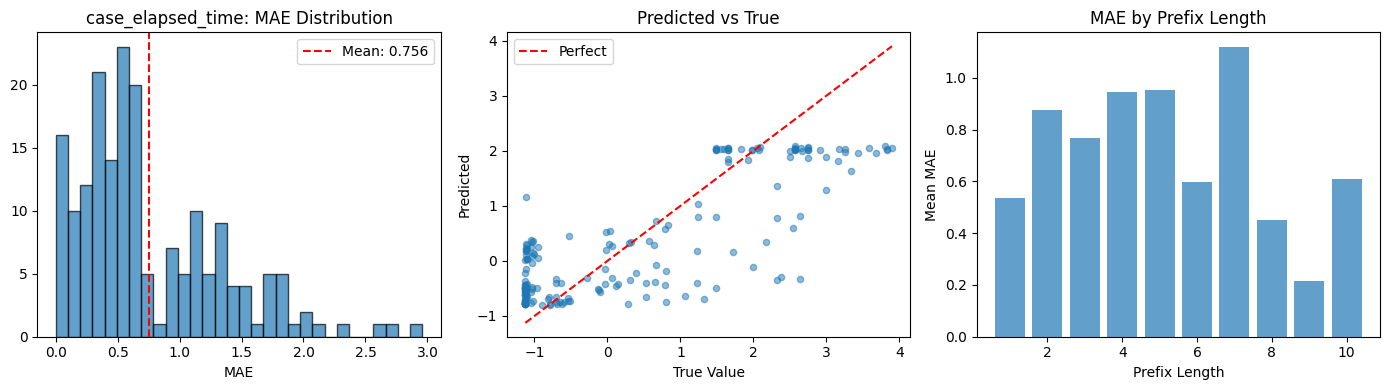

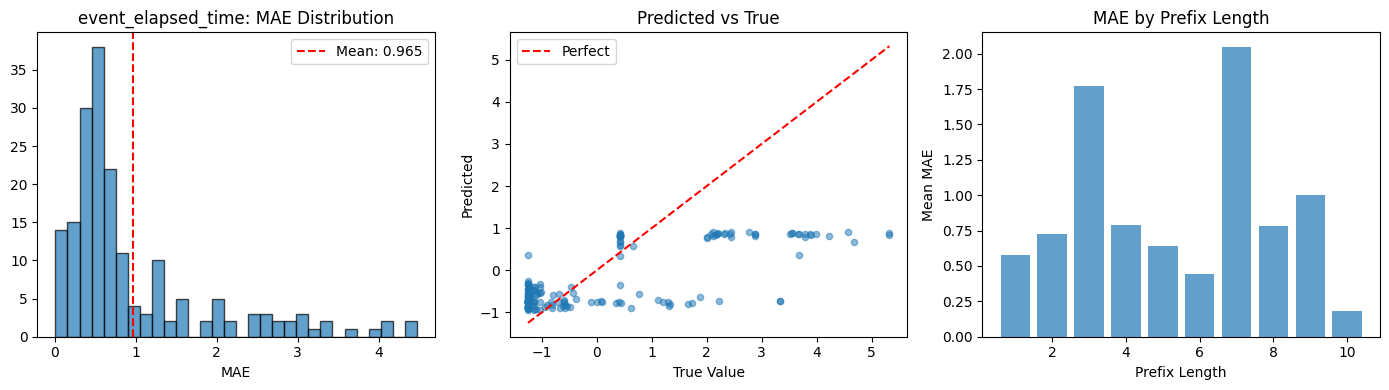

In [10]:
def plot_error_analysis(df, time_key):
    """Quick error distribution plots."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    valid = df.dropna(subset=['mae'])
    
    # MAE histogram
    axes[0].hist(valid['mae'], bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(valid['mae'].mean(), color='red', linestyle='--', label=f"Mean: {valid['mae'].mean():.3f}")
    axes[0].set_xlabel('MAE')
    axes[0].set_title(f'{time_key}: MAE Distribution')
    axes[0].legend()
    
    # Pred vs True
    axes[1].scatter(valid['true_value'], valid['pred_mean'], alpha=0.5, s=20)
    lims = [min(valid['true_value'].min(), valid['pred_mean'].min()),
            max(valid['true_value'].max(), valid['pred_mean'].max())]
    axes[1].plot(lims, lims, 'r--', label='Perfect')
    axes[1].set_xlabel('True Value')
    axes[1].set_ylabel('Predicted')
    axes[1].set_title('Predicted vs True')
    axes[1].legend()
    
    # MAE by prefix length
    mae_by_len = valid.groupby('prefix_len')['mae'].mean()
    axes[2].bar(mae_by_len.index, mae_by_len.values, alpha=0.7)
    axes[2].set_xlabel('Prefix Length')
    axes[2].set_ylabel('Mean MAE')
    axes[2].set_title('MAE by Prefix Length')
    
    plt.tight_layout()
    plt.show()


for time_key, df in results.items():
    plot_error_analysis(df, time_key)

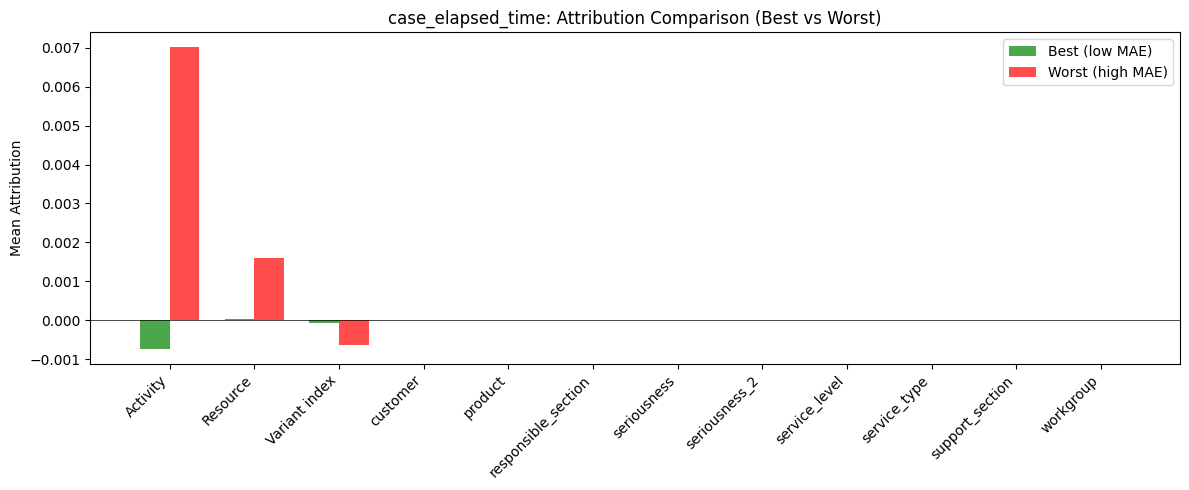

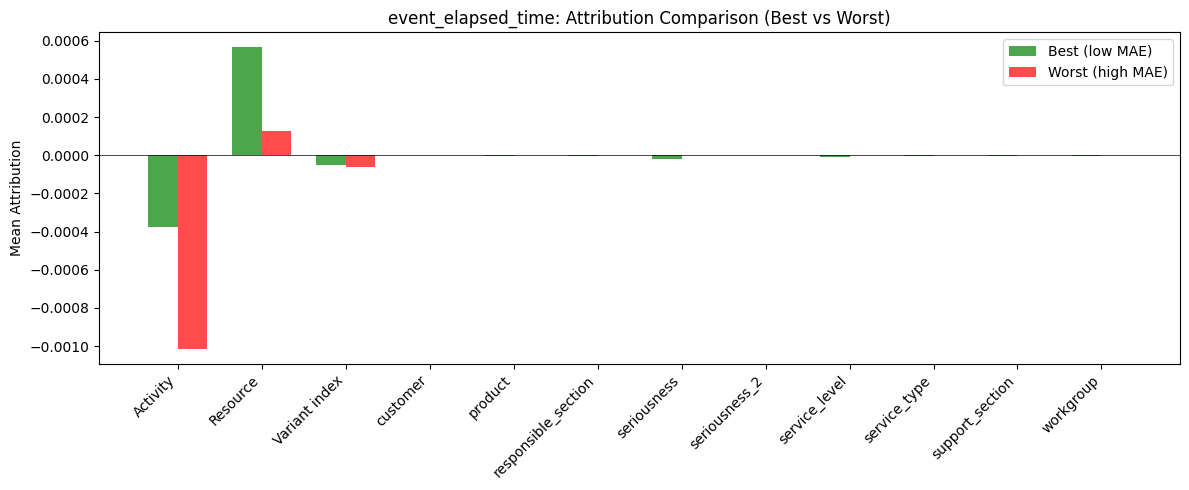

In [11]:
if COMPUTE_ATTRIBUTIONS:
    def plot_attribution_comparison(df, time_key):
        """Compare attributions between best and worst predictions."""
        valid = df[df['mae'].notna() & df['attributions'].notna()].copy()
        sorted_df = valid.sort_values('mae')
        
        n = min(len(sorted_df) // 4, 20)  # Top/bottom quartile or 20
        if n < 5:
            print(f"Not enough data for attribution comparison ({len(sorted_df)} samples)")
            return
        
        best = sorted_df.head(n)
        worst = sorted_df.tail(n)
        
        # Aggregate attributions
        def agg_attrs(subset):
            all_attrs = [r['attributions'] for _, r in subset.iterrows()]
            keys = set().union(*[a.keys() for a in all_attrs])
            return {k: np.mean([a.get(k, 0) for a in all_attrs]) for k in keys}
        
        best_attrs = agg_attrs(best)
        worst_attrs = agg_attrs(worst)
        
        features = sorted(best_attrs.keys())
        x = np.arange(len(features))
        
        fig, ax = plt.subplots(figsize=(12, 5))
        width = 0.35
        ax.bar(x - width/2, [best_attrs[f] for f in features], width, label='Best (low MAE)', color='green', alpha=0.7)
        ax.bar(x + width/2, [worst_attrs[f] for f in features], width, label='Worst (high MAE)', color='red', alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(features, rotation=45, ha='right')
        ax.set_ylabel('Mean Attribution')
        ax.set_title(f'{time_key}: Attribution Comparison (Best vs Worst)')
        ax.legend()
        ax.axhline(0, color='black', linewidth=0.5)
        plt.tight_layout()
        plt.show()
    
    for time_key, df in results.items():
        plot_attribution_comparison(df, time_key)
else:
    print("Attribution comparison skipped (COMPUTE_ATTRIBUTIONS=False)")

## Activity Value Breakdown

Analyze which **specific activity values** (e.g., "Assign seriousness", "Resolve ticket") in the prefix contribute most to accurate vs inaccurate temporal predictions.

This goes beyond just showing that "Activity" as a feature has high attribution - it shows which activity values matter most.

In [12]:
# Get activity label mapping
activity_idx_to_name = eval_helper.inverted_suffix_categories[eval_helper.concept_name_id]
print(f"Activity classes: {activity_idx_to_name}")

Activity classes: {1: 'Assign seriousness', 2: 'Closed', 3: 'Create SW anomaly', 4: 'DUPLICATE', 5: 'EOS', 6: 'INVALID', 7: 'Insert ticket', 8: 'RESOLVED', 9: 'Require upgrade', 10: 'Resolve SW anomaly', 11: 'Resolve ticket', 12: 'Schedule intervention', 13: 'Take in charge ticket', 14: 'VERIFIED', 15: 'Wait'}


In [13]:
def unpack_attrs_per_timestep(attr_tensor, prefix_len, prefix, eval_helper):
    """
    Unpack attributions per timestep, returning activity value and its attribution.
    
    Returns list of dicts: [{'activity': 'Assign seriousness', 'attribution': 0.123}, ...]
    """
    timestep_attrs = []
    
    # Get activity indices from prefix (last prefix_len positions)
    cat_prefix = prefix[0]
    activity_tensor = cat_prefix[eval_helper.concept_name_id]  # Shape: (1, seq_len)
    seq_len = activity_tensor.shape[1]
    start_idx = seq_len - prefix_len
    
    for t_rel in range(prefix_len):
        t_abs = start_idx + t_rel  # Absolute index in sequence
        t_attr = t_rel - prefix_len  # Index for attribution tensor (negative indexing)
        
        # Get activity value at this timestep
        activity_idx = activity_tensor[0, t_abs].item()
        activity_name = activity_idx_to_name.get(activity_idx, f"Unknown_{activity_idx}")
        
        # Get Activity feature attribution at this timestep
        sample = attr_tensor[t_attr, 0, :]
        
        # Activity is the first categorical feature
        activity_embed_dim = eval_helper.model.encoder.embeddings[0].embedding_dim
        activity_attr = sample[:activity_embed_dim].mean().detach().item()
        
        timestep_attrs.append({
            'timestep': t_rel,
            'activity_idx': activity_idx,
            'activity_name': activity_name,
            'activity_attribution': activity_attr
        })
    
    return timestep_attrs


def run_analysis_with_activity_breakdown(time_key):
    """Run temporal analysis with per-timestep activity breakdown."""
    results = []
    prefix_count = 0
    
    for case_name, full_case in tqdm(case_items, desc=f"{time_key} (activity breakdown)"):
        for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
            prefix_count += 1
            if prefix_count % SAMPLE_RATE != 0:
                continue
            
            try:
                preds = fast_forward(prefix)
                metrics = compute_temporal_metrics(preds, suffix, eval_helper, time_key)
                
                row = {
                    'case_name': case_name,
                    'prefix_len': prefix_len,
                    **metrics
                }
                
                if COMPUTE_ATTRIBUTIONS:
                    attrs = compute_ig(prefix, time_key, n_steps=IG_STEPS)
                    row['attributions'] = unpack_attrs(attrs, prefix_len, eval_helper)
                    row['activity_breakdown'] = unpack_attrs_per_timestep(attrs, prefix_len, prefix, eval_helper)
                
                results.append(row)
                
            except Exception as e:
                continue
    
    return pd.DataFrame(results)


# Run analysis with activity breakdown (reuses cached IG results structure)
if COMPUTE_ATTRIBUTIONS:
    print("Running analysis with activity value breakdown...")
    results_with_breakdown = {}
    
    if TEMPORAL_TARGET in ["case_elapsed_time", "both"]:
        results_with_breakdown['case_elapsed_time'] = run_analysis_with_activity_breakdown('case_elapsed_time')
        print(f"case_elapsed_time: {len(results_with_breakdown['case_elapsed_time'])} samples")
    
    if TEMPORAL_TARGET in ["event_elapsed_time", "both"]:
        results_with_breakdown['event_elapsed_time'] = run_analysis_with_activity_breakdown('event_elapsed_time')
        print(f"event_elapsed_time: {len(results_with_breakdown['event_elapsed_time'])} samples")
else:
    print("Skipped - COMPUTE_ATTRIBUTIONS is False")

Running analysis with activity value breakdown...


case_elapsed_time (activity breakdown):   0%|          | 0/50 [00:00<?, ?it/s]

case_elapsed_time: 185 samples


event_elapsed_time (activity breakdown):   0%|          | 0/50 [00:00<?, ?it/s]

event_elapsed_time: 185 samples


In [14]:
def aggregate_by_activity_value(df, top_pct=0.25, bottom_pct=0.25):
    """
    Aggregate activity attributions by activity value for best vs worst predictions.
    
    Args:
        df: DataFrame with 'mae' and 'activity_breakdown' columns
        top_pct: Top percentage to consider as "best" (lowest MAE)
        bottom_pct: Bottom percentage to consider as "worst" (highest MAE)
    
    Returns:
        Dict with 'best' and 'worst' activity value aggregations
    """
    valid = df[df['mae'].notna() & df['activity_breakdown'].notna()].copy()
    sorted_df = valid.sort_values('mae')
    
    n_best = max(1, int(len(sorted_df) * top_pct))
    n_worst = max(1, int(len(sorted_df) * bottom_pct))
    
    best_df = sorted_df.head(n_best)
    worst_df = sorted_df.tail(n_worst)
    
    def agg_activity_attrs(subset):
        """Aggregate attributions by activity value."""
        activity_attrs = defaultdict(list)
        
        for _, row in subset.iterrows():
            for step in row['activity_breakdown']:
                act_name = step['activity_name']
                act_attr = step['activity_attribution']
                activity_attrs[act_name].append(act_attr)
        
        # Compute mean and count for each activity
        result = {}
        for act_name, attrs in activity_attrs.items():
            result[act_name] = {
                'mean_attr': np.mean(attrs),
                'abs_mean_attr': np.mean([abs(a) for a in attrs]),
                'std_attr': np.std(attrs) if len(attrs) > 1 else 0,
                'count': len(attrs),
                'sum_attr': np.sum(attrs)
            }
        return result
    
    return {
        'best': agg_activity_attrs(best_df),
        'worst': agg_activity_attrs(worst_df),
        'n_best': n_best,
        'n_worst': n_worst,
        'best_mae_range': (best_df['mae'].min(), best_df['mae'].max()),
        'worst_mae_range': (worst_df['mae'].min(), worst_df['mae'].max())
    }


if COMPUTE_ATTRIBUTIONS:
    activity_breakdowns = {}
    
    for time_key, df in results_with_breakdown.items():
        activity_breakdowns[time_key] = aggregate_by_activity_value(df)
        
        print(f"\n{'='*70}")
        print(f"ACTIVITY VALUE BREAKDOWN: {time_key.upper()}")
        print(f"{'='*70}")
        
        breakdown = activity_breakdowns[time_key]
        print(f"\nBest predictions (n={breakdown['n_best']}, MAE range: {breakdown['best_mae_range'][0]:.4f} - {breakdown['best_mae_range'][1]:.4f})")
        print(f"Worst predictions (n={breakdown['n_worst']}, MAE range: {breakdown['worst_mae_range'][0]:.4f} - {breakdown['worst_mae_range'][1]:.4f})")
        
        # Show best predictions breakdown
        print(f"\n--- Activities in BEST temporal predictions (by |attribution|) ---")
        best_sorted = sorted(breakdown['best'].items(), key=lambda x: x[1]['abs_mean_attr'], reverse=True)
        for act_name, stats in best_sorted[:10]:
            print(f"  {act_name:30s}: mean={stats['mean_attr']:+.6f}, |mean|={stats['abs_mean_attr']:.6f}, count={stats['count']}")
        
        # Show worst predictions breakdown
        print(f"\n--- Activities in WORST temporal predictions (by |attribution|) ---")
        worst_sorted = sorted(breakdown['worst'].items(), key=lambda x: x[1]['abs_mean_attr'], reverse=True)
        for act_name, stats in worst_sorted[:10]:
            print(f"  {act_name:30s}: mean={stats['mean_attr']:+.6f}, |mean|={stats['abs_mean_attr']:.6f}, count={stats['count']}")


ACTIVITY VALUE BREAKDOWN: CASE_ELAPSED_TIME

Best predictions (n=46, MAE range: 0.0005 - 0.3532)
Worst predictions (n=46, MAE range: 1.1392 - 2.9593)

--- Activities in BEST temporal predictions (by |attribution|) ---
  Resolve ticket                : mean=-0.004548, |mean|=0.009039, count=9
  Take in charge ticket         : mean=+0.001375, |mean|=0.001853, count=45
  Schedule intervention         : mean=-0.000660, |mean|=0.000660, count=3
  Wait                          : mean=-0.000317, |mean|=0.000317, count=19
  Assign seriousness            : mean=-0.000012, |mean|=0.000012, count=47
  Insert ticket                 : mean=-0.000001, |mean|=0.000001, count=2

--- Activities in WORST temporal predictions (by |attribution|) ---
  Resolve ticket                : mean=+0.008419, |mean|=0.020570, count=14
  Wait                          : mean=+0.019483, |mean|=0.019825, count=22
  Require upgrade               : mean=-0.001932, |mean|=0.001932, count=3
  Take in charge ticket         

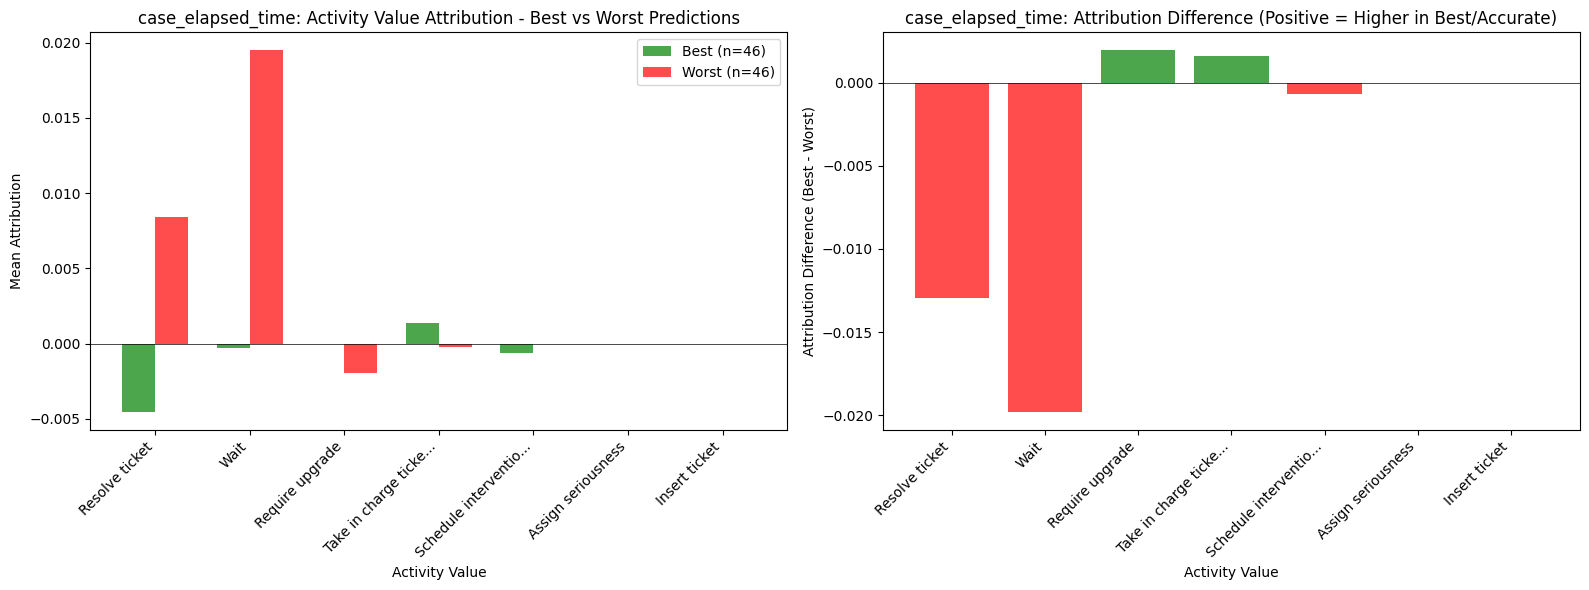


Interpretation for case_elapsed_time:
--------------------------------------------------
  'Resolve ticket': less attributed in inaccurate predictions (diff: -0.012967)
  'Wait': less attributed in inaccurate predictions (diff: -0.019800)
  'Require upgrade': more attributed in accurate predictions (diff: +0.001932)
  'Take in charge ticket': more attributed in accurate predictions (diff: +0.001617)
  'Schedule intervention': less attributed in inaccurate predictions (diff: -0.000660)


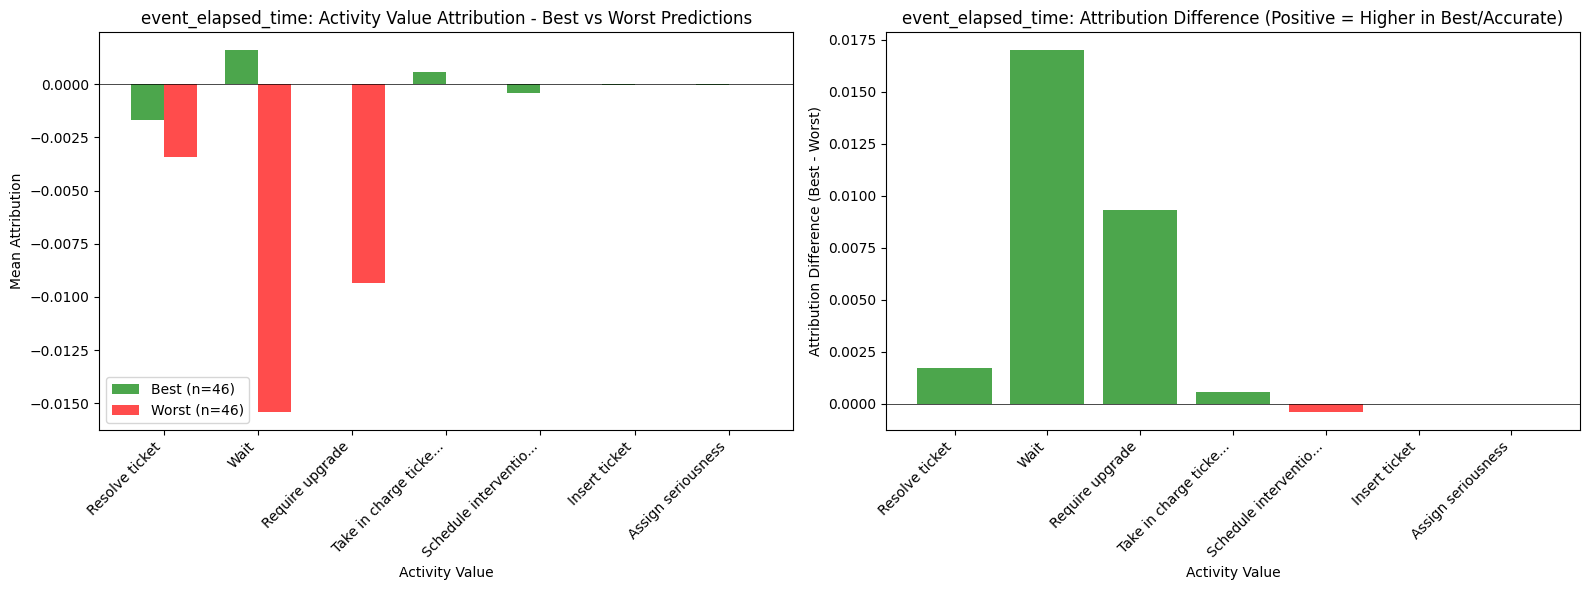


Interpretation for event_elapsed_time:
--------------------------------------------------
  'Resolve ticket': more attributed in accurate predictions (diff: +0.001717)
  'Wait': more attributed in accurate predictions (diff: +0.016982)
  'Require upgrade': more attributed in accurate predictions (diff: +0.009334)
  'Take in charge ticket': more attributed in accurate predictions (diff: +0.000578)
  'Schedule intervention': less attributed in inaccurate predictions (diff: -0.000399)


In [15]:
def plot_activity_value_comparison(breakdown, time_key, top_n=10):
    """
    Visualize activity value attributions: best vs worst predictions.
    """
    best = breakdown['best']
    worst = breakdown['worst']
    
    # Get all activities present in either best or worst
    all_activities = set(best.keys()) | set(worst.keys())
    
    # Sort by max absolute attribution across best/worst
    def max_abs_attr(act):
        b = best.get(act, {}).get('abs_mean_attr', 0)
        w = worst.get(act, {}).get('abs_mean_attr', 0)
        return max(b, w)
    
    sorted_activities = sorted(all_activities, key=max_abs_attr, reverse=True)[:top_n]
    
    if not sorted_activities:
        print(f"No activity data for {time_key}")
        return
    
    # Prepare data
    best_vals = [best.get(a, {}).get('mean_attr', 0) for a in sorted_activities]
    worst_vals = [worst.get(a, {}).get('mean_attr', 0) for a in sorted_activities]
    best_counts = [best.get(a, {}).get('count', 0) for a in sorted_activities]
    worst_counts = [worst.get(a, {}).get('count', 0) for a in sorted_activities]
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Mean attribution comparison
    x = np.arange(len(sorted_activities))
    width = 0.35
    
    ax1 = axes[0]
    bars1 = ax1.bar(x - width/2, best_vals, width, label=f'Best (n={breakdown["n_best"]})', color='green', alpha=0.7)
    bars2 = ax1.bar(x + width/2, worst_vals, width, label=f'Worst (n={breakdown["n_worst"]})', color='red', alpha=0.7)
    
    ax1.set_xlabel('Activity Value')
    ax1.set_ylabel('Mean Attribution')
    ax1.set_title(f'{time_key}: Activity Value Attribution - Best vs Worst Predictions')
    ax1.set_xticks(x)
    ax1.set_xticklabels([a[:20] + '...' if len(a) > 20 else a for a in sorted_activities], 
                         rotation=45, ha='right')
    ax1.legend()
    ax1.axhline(0, color='black', linewidth=0.5)
    
    # Plot 2: Difference (Best - Worst)
    ax2 = axes[1]
    diff = [b - w for b, w in zip(best_vals, worst_vals)]
    colors = ['green' if d > 0 else 'red' for d in diff]
    ax2.bar(x, diff, color=colors, alpha=0.7)
    
    ax2.set_xlabel('Activity Value')
    ax2.set_ylabel('Attribution Difference (Best - Worst)')
    ax2.set_title(f'{time_key}: Attribution Difference (Positive = Higher in Best/Accurate)')
    ax2.set_xticks(x)
    ax2.set_xticklabels([a[:20] + '...' if len(a) > 20 else a for a in sorted_activities], 
                         rotation=45, ha='right')
    ax2.axhline(0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Print interpretation
    print(f"\nInterpretation for {time_key}:")
    print("-" * 50)
    for i, act in enumerate(sorted_activities[:5]):
        d = diff[i]
        if abs(d) > 0.0001:
            direction = "more" if d > 0 else "less"
            pred_type = "accurate" if d > 0 else "inaccurate"
            print(f"  '{act}': {direction} attributed in {pred_type} predictions (diff: {d:+.6f})")


if COMPUTE_ATTRIBUTIONS:
    for time_key, breakdown in activity_breakdowns.items():
        plot_activity_value_comparison(breakdown, time_key, top_n=10)

### Activity Value Heatmap

Show attribution patterns across all activity values for best vs worst temporal predictions.

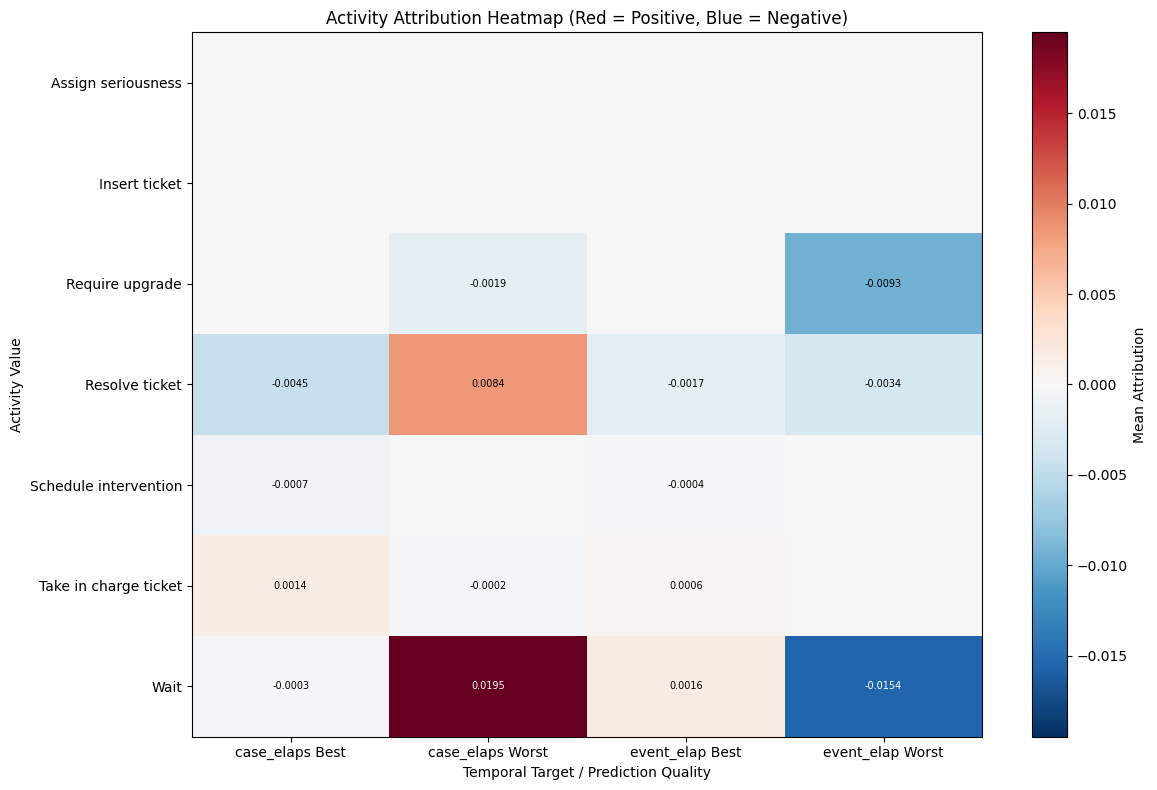

In [16]:
def create_activity_heatmap(activity_breakdowns):
    """
    Create a combined heatmap showing activity attributions for all temporal targets.
    """
    # Collect all unique activities across all breakdowns
    all_activities = set()
    for time_key, breakdown in activity_breakdowns.items():
        all_activities.update(breakdown['best'].keys())
        all_activities.update(breakdown['worst'].keys())
    
    all_activities = sorted(all_activities)
    
    if not all_activities:
        print("No activity data to visualize")
        return
    
    # Build data matrix: rows = activities, cols = (best/worst) x time_keys
    col_labels = []
    data_matrix = []
    
    for time_key, breakdown in activity_breakdowns.items():
        col_labels.append(f"{time_key[:10]} Best")
        col_labels.append(f"{time_key[:10]} Worst")
    
    for act in all_activities:
        row = []
        for time_key, breakdown in activity_breakdowns.items():
            best_val = breakdown['best'].get(act, {}).get('mean_attr', 0)
            worst_val = breakdown['worst'].get(act, {}).get('mean_attr', 0)
            row.extend([best_val, worst_val])
        data_matrix.append(row)
    
    data_matrix = np.array(data_matrix)
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(12, max(8, len(all_activities) * 0.4)))
    
    vmax = np.abs(data_matrix).max()
    im = ax.imshow(data_matrix, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    
    # Labels
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=0)
    ax.set_yticks(range(len(all_activities)))
    ax.set_yticklabels([a[:25] + '...' if len(a) > 25 else a for a in all_activities])
    
    ax.set_xlabel('Temporal Target / Prediction Quality')
    ax.set_ylabel('Activity Value')
    ax.set_title('Activity Attribution Heatmap (Red = Positive, Blue = Negative)')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Mean Attribution')
    
    # Add value annotations
    for i in range(len(all_activities)):
        for j in range(len(col_labels)):
            val = data_matrix[i, j]
            if abs(val) > 0.0001:
                color = 'white' if abs(val) > vmax * 0.5 else 'black'
                ax.text(j, i, f'{val:.4f}', ha='center', va='center', 
                       color=color, fontsize=7)
    
    plt.tight_layout()
    plt.show()


if COMPUTE_ATTRIBUTIONS:
    create_activity_heatmap(activity_breakdowns)

## Resource Value Breakdown

Analyze which **specific resource values** (e.g., "Value 1", "Value 2") in the prefix contribute most to accurate vs inaccurate temporal predictions.

This mirrors the Activity analysis but for the Resource feature.

In [17]:
# Get resource label mapping
# Resource is the second categorical attribute (index 1)
RESOURCE_IDX = 1
resource_idx_to_name = eval_helper.inverted_suffix_categories[RESOURCE_IDX]
print(f"Resource classes ({len(resource_idx_to_name)} total):")
for idx, name in list(resource_idx_to_name.items())[:15]:
    print(f"  {idx}: {name}")
if len(resource_idx_to_name) > 15:
    print(f"  ... and {len(resource_idx_to_name) - 15} more")

Resource classes (23 total):
  1: EOS
  2: Value 1
  3: Value 10
  4: Value 11
  5: Value 12
  6: Value 13
  7: Value 14
  8: Value 15
  9: Value 16
  10: Value 17
  11: Value 18
  12: Value 19
  13: Value 2
  14: Value 20
  15: Value 21
  ... and 8 more


In [18]:
def unpack_attrs_per_timestep_resource(attr_tensor, prefix_len, prefix, eval_helper):
    """
    Unpack attributions per timestep, returning resource value and its attribution.
    
    Returns list of dicts: [{'resource': 'Value 1', 'attribution': 0.123}, ...]
    """
    timestep_attrs = []
    
    # Get resource indices from prefix (last prefix_len positions)
    cat_prefix = prefix[0]
    resource_tensor = cat_prefix[RESOURCE_IDX]  # Shape: (1, seq_len)
    seq_len = resource_tensor.shape[1]
    start_idx = seq_len - prefix_len
    
    # Calculate offset for resource embeddings in the concatenated embedding vector
    # Activity embedding comes first, then Resource
    activity_embed_dim = eval_helper.model.encoder.embeddings[0].embedding_dim
    resource_embed_dim = eval_helper.model.encoder.embeddings[RESOURCE_IDX].embedding_dim
    
    for t_rel in range(prefix_len):
        t_abs = start_idx + t_rel  # Absolute index in sequence
        t_attr = t_rel - prefix_len  # Index for attribution tensor (negative indexing)
        
        # Get resource value at this timestep
        resource_idx = resource_tensor[0, t_abs].item()
        resource_name = resource_idx_to_name.get(resource_idx, f"Unknown_{resource_idx}")
        
        # Get Resource feature attribution at this timestep
        sample = attr_tensor[t_attr, 0, :]
        
        # Resource attribution starts after Activity embedding
        resource_attr = sample[activity_embed_dim:activity_embed_dim + resource_embed_dim].mean().detach().item()
        
        timestep_attrs.append({
            'timestep': t_rel,
            'resource_idx': resource_idx,
            'resource_name': resource_name,
            'resource_attribution': resource_attr
        })
    
    return timestep_attrs


def run_analysis_with_resource_breakdown(time_key):
    """Run temporal analysis with per-timestep resource breakdown."""
    results = []
    prefix_count = 0
    
    for case_name, full_case in tqdm(case_items, desc=f"{time_key} (resource breakdown)"):
        for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
            prefix_count += 1
            if prefix_count % SAMPLE_RATE != 0:
                continue
            
            try:
                preds = fast_forward(prefix)
                metrics = compute_temporal_metrics(preds, suffix, eval_helper, time_key)
                
                row = {
                    'case_name': case_name,
                    'prefix_len': prefix_len,
                    **metrics
                }
                
                if COMPUTE_ATTRIBUTIONS:
                    attrs = compute_ig(prefix, time_key, n_steps=IG_STEPS)
                    row['attributions'] = unpack_attrs(attrs, prefix_len, eval_helper)
                    row['resource_breakdown'] = unpack_attrs_per_timestep_resource(attrs, prefix_len, prefix, eval_helper)
                
                results.append(row)
                
            except Exception as e:
                continue
    
    return pd.DataFrame(results)


# Run analysis with resource breakdown
if COMPUTE_ATTRIBUTIONS:
    print("Running analysis with resource value breakdown...")
    results_with_resource_breakdown = {}
    
    if TEMPORAL_TARGET in ["case_elapsed_time", "both"]:
        results_with_resource_breakdown['case_elapsed_time'] = run_analysis_with_resource_breakdown('case_elapsed_time')
        print(f"case_elapsed_time: {len(results_with_resource_breakdown['case_elapsed_time'])} samples")
    
    if TEMPORAL_TARGET in ["event_elapsed_time", "both"]:
        results_with_resource_breakdown['event_elapsed_time'] = run_analysis_with_resource_breakdown('event_elapsed_time')
        print(f"event_elapsed_time: {len(results_with_resource_breakdown['event_elapsed_time'])} samples")
else:
    print("Skipped - COMPUTE_ATTRIBUTIONS is False")

Running analysis with resource value breakdown...


case_elapsed_time (resource breakdown):   0%|          | 0/50 [00:00<?, ?it/s]

case_elapsed_time: 185 samples


event_elapsed_time (resource breakdown):   0%|          | 0/50 [00:00<?, ?it/s]

event_elapsed_time: 185 samples


In [19]:
def aggregate_by_resource_value(df, top_pct=0.25, bottom_pct=0.25):
    """
    Aggregate resource attributions by resource value for best vs worst predictions.
    
    Args:
        df: DataFrame with 'mae' and 'resource_breakdown' columns
        top_pct: Top percentage to consider as "best" (lowest MAE)
        bottom_pct: Bottom percentage to consider as "worst" (highest MAE)
    
    Returns:
        Dict with 'best' and 'worst' resource value aggregations
    """
    valid = df[df['mae'].notna() & df['resource_breakdown'].notna()].copy()
    sorted_df = valid.sort_values('mae')
    
    n_best = max(1, int(len(sorted_df) * top_pct))
    n_worst = max(1, int(len(sorted_df) * bottom_pct))
    
    best_df = sorted_df.head(n_best)
    worst_df = sorted_df.tail(n_worst)
    
    def agg_resource_attrs(subset):
        """Aggregate attributions by resource value."""
        resource_attrs = defaultdict(list)
        
        for _, row in subset.iterrows():
            for step in row['resource_breakdown']:
                res_name = step['resource_name']
                res_attr = step['resource_attribution']
                resource_attrs[res_name].append(res_attr)
        
        # Compute mean and count for each resource
        result = {}
        for res_name, attrs in resource_attrs.items():
            result[res_name] = {
                'mean_attr': np.mean(attrs),
                'abs_mean_attr': np.mean([abs(a) for a in attrs]),
                'std_attr': np.std(attrs) if len(attrs) > 1 else 0,
                'count': len(attrs),
                'sum_attr': np.sum(attrs)
            }
        return result
    
    return {
        'best': agg_resource_attrs(best_df),
        'worst': agg_resource_attrs(worst_df),
        'n_best': n_best,
        'n_worst': n_worst,
        'best_mae_range': (best_df['mae'].min(), best_df['mae'].max()),
        'worst_mae_range': (worst_df['mae'].min(), worst_df['mae'].max())
    }


if COMPUTE_ATTRIBUTIONS:
    resource_breakdowns = {}
    
    for time_key, df in results_with_resource_breakdown.items():
        resource_breakdowns[time_key] = aggregate_by_resource_value(df)
        
        print(f"\n{'='*70}")
        print(f"RESOURCE VALUE BREAKDOWN: {time_key.upper()}")
        print(f"{'='*70}")
        
        breakdown = resource_breakdowns[time_key]
        print(f"\nBest predictions (n={breakdown['n_best']}, MAE range: {breakdown['best_mae_range'][0]:.4f} - {breakdown['best_mae_range'][1]:.4f})")
        print(f"Worst predictions (n={breakdown['n_worst']}, MAE range: {breakdown['worst_mae_range'][0]:.4f} - {breakdown['worst_mae_range'][1]:.4f})")
        
        # Show best predictions breakdown
        print(f"\n--- Resources in BEST temporal predictions (by |attribution|) ---")
        best_sorted = sorted(breakdown['best'].items(), key=lambda x: x[1]['abs_mean_attr'], reverse=True)
        for res_name, stats in best_sorted[:10]:
            print(f"  {res_name:30s}: mean={stats['mean_attr']:+.6f}, |mean|={stats['abs_mean_attr']:.6f}, count={stats['count']}")
        
        # Show worst predictions breakdown
        print(f"\n--- Resources in WORST temporal predictions (by |attribution|) ---")
        worst_sorted = sorted(breakdown['worst'].items(), key=lambda x: x[1]['abs_mean_attr'], reverse=True)
        for res_name, stats in worst_sorted[:10]:
            print(f"  {res_name:30s}: mean={stats['mean_attr']:+.6f}, |mean|={stats['abs_mean_attr']:.6f}, count={stats['count']}")


RESOURCE VALUE BREAKDOWN: CASE_ELAPSED_TIME

Best predictions (n=46, MAE range: 0.0005 - 0.3532)
Worst predictions (n=46, MAE range: 1.1392 - 2.9593)

--- Resources in BEST temporal predictions (by |attribution|) ---
  Value 20                      : mean=-0.002217, |mean|=0.002217, count=1
  Value 13                      : mean=-0.000965, |mean|=0.000966, count=5
  Value 2                       : mean=+0.000557, |mean|=0.000573, count=32
  Value 11                      : mean=-0.000521, |mean|=0.000522, count=11
  Value 1                       : mean=+0.000099, |mean|=0.000135, count=21
  Value 12                      : mean=-0.000120, |mean|=0.000126, count=12
  Value 8                       : mean=+0.000092, |mean|=0.000116, count=24
  Value 9                       : mean=+0.000093, |mean|=0.000098, count=10
  Value 4                       : mean=+0.000010, |mean|=0.000047, count=5
  Value 14                      : mean=-0.000008, |mean|=0.000010, count=4

--- Resources in WORST te

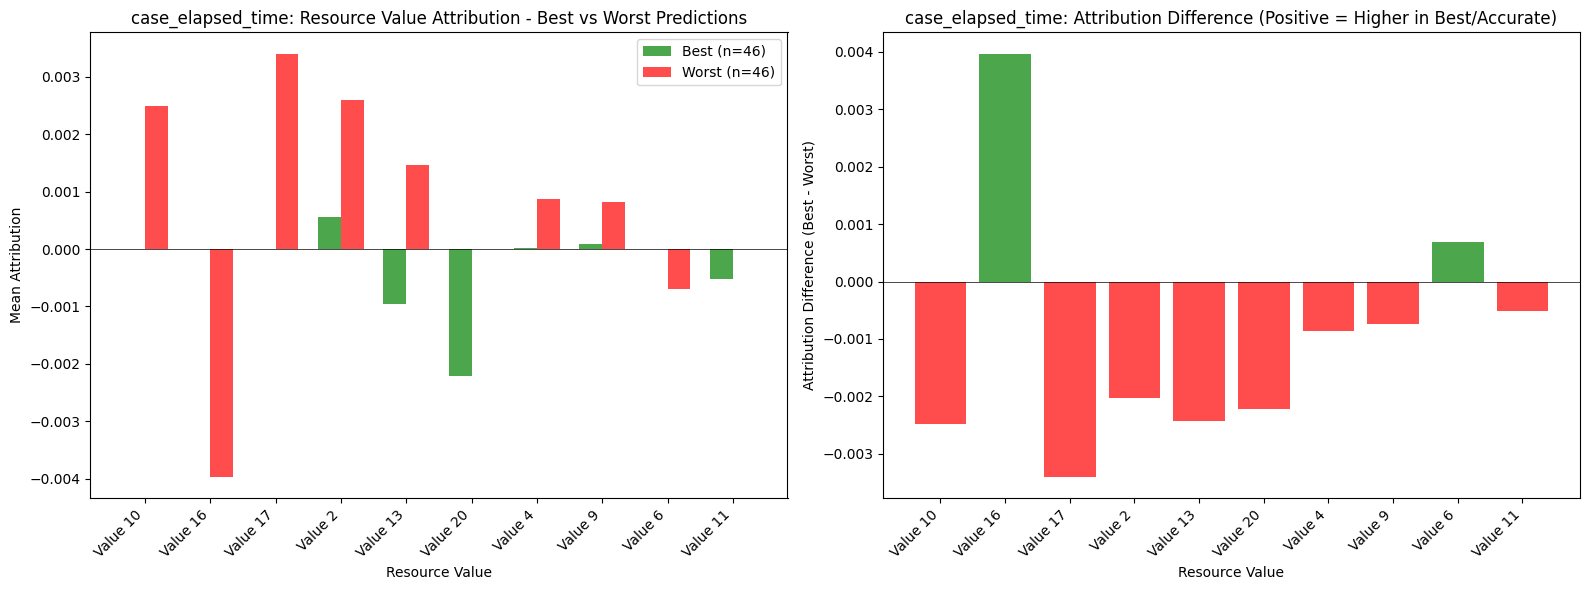


Interpretation for case_elapsed_time:
--------------------------------------------------
  'Value 10': less attributed in inaccurate predictions (diff: -0.002491)
  'Value 16': more attributed in accurate predictions (diff: +0.003973)
  'Value 17': less attributed in inaccurate predictions (diff: -0.003407)
  'Value 2': less attributed in inaccurate predictions (diff: -0.002033)
  'Value 13': less attributed in inaccurate predictions (diff: -0.002430)


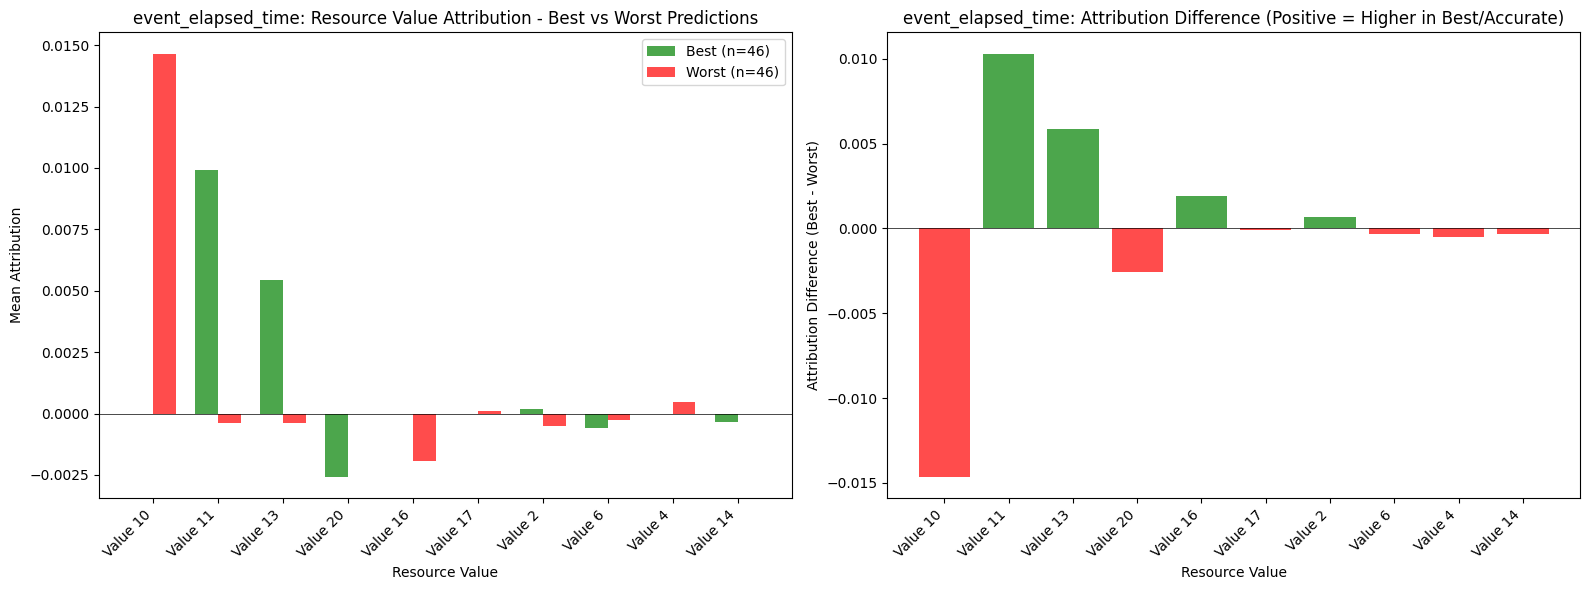


Interpretation for event_elapsed_time:
--------------------------------------------------
  'Value 10': less attributed in inaccurate predictions (diff: -0.014659)
  'Value 11': more attributed in accurate predictions (diff: +0.010312)
  'Value 13': more attributed in accurate predictions (diff: +0.005843)
  'Value 20': less attributed in inaccurate predictions (diff: -0.002585)
  'Value 16': more attributed in accurate predictions (diff: +0.001919)


In [20]:
def plot_resource_value_comparison(breakdown, time_key, top_n=10):
    """
    Visualize resource value attributions: best vs worst predictions.
    """
    best = breakdown['best']
    worst = breakdown['worst']
    
    # Get all resources present in either best or worst
    all_resources = set(best.keys()) | set(worst.keys())
    
    # Sort by max absolute attribution across best/worst
    def max_abs_attr(res):
        b = best.get(res, {}).get('abs_mean_attr', 0)
        w = worst.get(res, {}).get('abs_mean_attr', 0)
        return max(b, w)
    
    sorted_resources = sorted(all_resources, key=max_abs_attr, reverse=True)[:top_n]
    
    if not sorted_resources:
        print(f"No resource data for {time_key}")
        return
    
    # Prepare data
    best_vals = [best.get(r, {}).get('mean_attr', 0) for r in sorted_resources]
    worst_vals = [worst.get(r, {}).get('mean_attr', 0) for r in sorted_resources]
    best_counts = [best.get(r, {}).get('count', 0) for r in sorted_resources]
    worst_counts = [worst.get(r, {}).get('count', 0) for r in sorted_resources]
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Mean attribution comparison
    x = np.arange(len(sorted_resources))
    width = 0.35
    
    ax1 = axes[0]
    bars1 = ax1.bar(x - width/2, best_vals, width, label=f'Best (n={breakdown["n_best"]})', color='green', alpha=0.7)
    bars2 = ax1.bar(x + width/2, worst_vals, width, label=f'Worst (n={breakdown["n_worst"]})', color='red', alpha=0.7)
    
    ax1.set_xlabel('Resource Value')
    ax1.set_ylabel('Mean Attribution')
    ax1.set_title(f'{time_key}: Resource Value Attribution - Best vs Worst Predictions')
    ax1.set_xticks(x)
    ax1.set_xticklabels([r[:20] + '...' if len(str(r)) > 20 else str(r) for r in sorted_resources], 
                         rotation=45, ha='right')
    ax1.legend()
    ax1.axhline(0, color='black', linewidth=0.5)
    
    # Plot 2: Difference (Best - Worst)
    ax2 = axes[1]
    diff = [b - w for b, w in zip(best_vals, worst_vals)]
    colors = ['green' if d > 0 else 'red' for d in diff]
    ax2.bar(x, diff, color=colors, alpha=0.7)
    
    ax2.set_xlabel('Resource Value')
    ax2.set_ylabel('Attribution Difference (Best - Worst)')
    ax2.set_title(f'{time_key}: Attribution Difference (Positive = Higher in Best/Accurate)')
    ax2.set_xticks(x)
    ax2.set_xticklabels([r[:20] + '...' if len(str(r)) > 20 else str(r) for r in sorted_resources], 
                         rotation=45, ha='right')
    ax2.axhline(0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Print interpretation
    print(f"\nInterpretation for {time_key}:")
    print("-" * 50)
    for i, res in enumerate(sorted_resources[:5]):
        d = diff[i]
        if abs(d) > 0.0001:
            direction = "more" if d > 0 else "less"
            pred_type = "accurate" if d > 0 else "inaccurate"
            print(f"  '{res}': {direction} attributed in {pred_type} predictions (diff: {d:+.6f})")


if COMPUTE_ATTRIBUTIONS:
    for time_key, breakdown in resource_breakdowns.items():
        plot_resource_value_comparison(breakdown, time_key, top_n=10)

### Resource Value Heatmap

Show attribution patterns across all resource values for best vs worst temporal predictions.

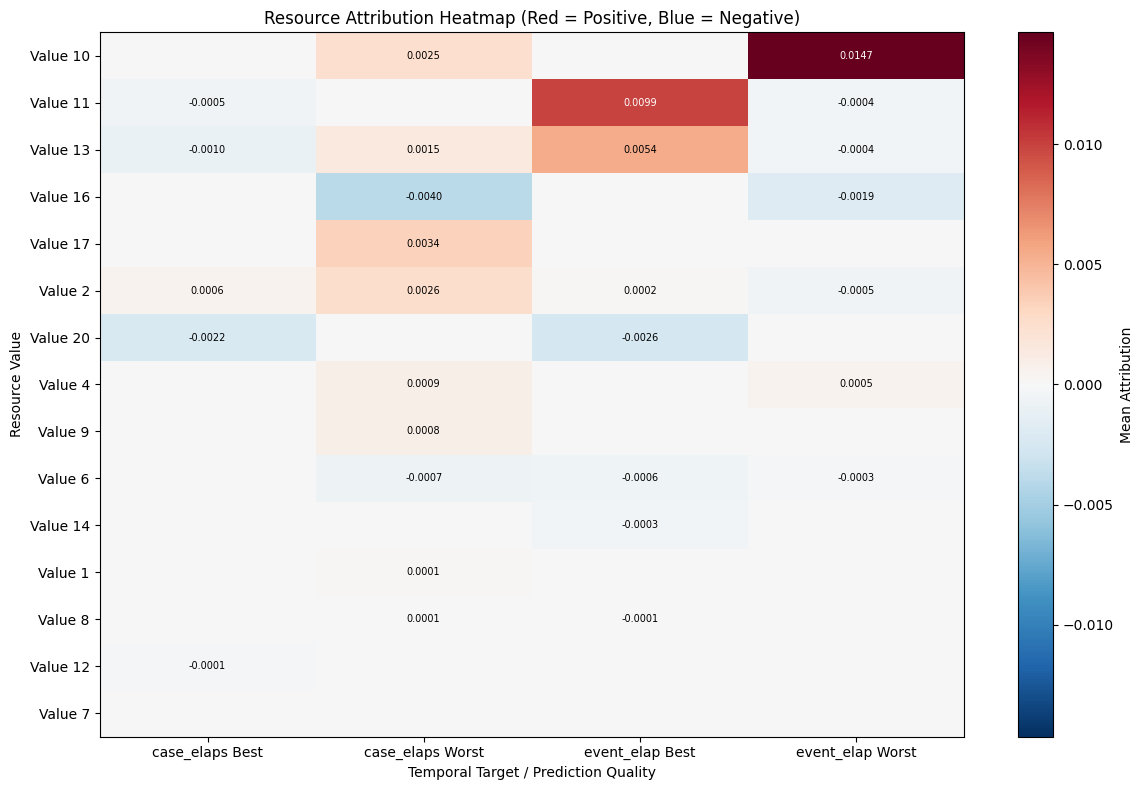

In [21]:
def create_resource_heatmap(resource_breakdowns, top_n=15):
    """
    Create a combined heatmap showing resource attributions for all temporal targets.
    
    Args:
        resource_breakdowns: Dict with resource breakdown data per time_key
        top_n: Number of top resources to show (sorted by max absolute attribution)
    """
    # Collect all unique resources across all breakdowns
    all_resources = set()
    for time_key, breakdown in resource_breakdowns.items():
        all_resources.update(breakdown['best'].keys())
        all_resources.update(breakdown['worst'].keys())
    
    if not all_resources:
        print("No resource data to visualize")
        return
    
    # Sort resources by max absolute attribution and take top_n
    def max_abs_attr(res):
        max_attr = 0
        for breakdown in resource_breakdowns.values():
            b = breakdown['best'].get(res, {}).get('abs_mean_attr', 0)
            w = breakdown['worst'].get(res, {}).get('abs_mean_attr', 0)
            max_attr = max(max_attr, b, w)
        return max_attr
    
    sorted_resources = sorted(all_resources, key=max_abs_attr, reverse=True)[:top_n]
    
    # Build data matrix: rows = resources, cols = (best/worst) x time_keys
    col_labels = []
    data_matrix = []
    
    for time_key, breakdown in resource_breakdowns.items():
        col_labels.append(f"{time_key[:10]} Best")
        col_labels.append(f"{time_key[:10]} Worst")
    
    for res in sorted_resources:
        row = []
        for time_key, breakdown in resource_breakdowns.items():
            best_val = breakdown['best'].get(res, {}).get('mean_attr', 0)
            worst_val = breakdown['worst'].get(res, {}).get('mean_attr', 0)
            row.extend([best_val, worst_val])
        data_matrix.append(row)
    
    data_matrix = np.array(data_matrix)
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(12, max(8, len(sorted_resources) * 0.4)))
    
    vmax = np.abs(data_matrix).max()
    im = ax.imshow(data_matrix, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
    
    # Labels
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=0)
    ax.set_yticks(range(len(sorted_resources)))
    ax.set_yticklabels([str(r)[:25] + '...' if len(str(r)) > 25 else str(r) for r in sorted_resources])
    
    ax.set_xlabel('Temporal Target / Prediction Quality')
    ax.set_ylabel('Resource Value')
    ax.set_title('Resource Attribution Heatmap (Red = Positive, Blue = Negative)')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Mean Attribution')
    
    # Add value annotations
    for i in range(len(sorted_resources)):
        for j in range(len(col_labels)):
            val = data_matrix[i, j]
            if abs(val) > 0.0001:
                color = 'white' if abs(val) > vmax * 0.5 else 'black'
                ax.text(j, i, f'{val:.4f}', ha='center', va='center', 
                       color=color, fontsize=7)
    
    plt.tight_layout()
    plt.show()


if COMPUTE_ATTRIBUTIONS:
    create_resource_heatmap(resource_breakdowns)

### Key Insights: Resource Values and Temporal Prediction Accuracy

In [22]:
def summarize_resource_insights(resource_breakdowns):
    """
    Generate summary insights about which resource values matter for temporal predictions.
    """
    print("="*80)
    print("KEY INSIGHTS: RESOURCE VALUES AND TEMPORAL PREDICTION ACCURACY")
    print("="*80)
    
    for time_key, breakdown in resource_breakdowns.items():
        print(f"\n{'-'*40}")
        print(f"{time_key.upper()}")
        print(f"{'-'*40}")
        
        best = breakdown['best']
        worst = breakdown['worst']
        
        # Find resources with biggest positive difference (higher in accurate predictions)
        all_resources = set(best.keys()) | set(worst.keys())
        diffs = []
        for res in all_resources:
            b = best.get(res, {}).get('mean_attr', 0)
            w = worst.get(res, {}).get('mean_attr', 0)
            b_count = best.get(res, {}).get('count', 0)
            w_count = worst.get(res, {}).get('count', 0)
            diffs.append((res, b - w, b, w, b_count, w_count))
        
        diffs.sort(key=lambda x: x[1], reverse=True)
        
        print("\nResources MOST associated with ACCURATE temporal predictions:")
        print("(Higher positive attribution in best predictions)")
        for res, diff, b, w, bc, wc in diffs[:5]:
            if diff > 0:
                print(f"  + {str(res):30s}: best={b:+.6f} (n={bc}), worst={w:+.6f} (n={wc}), diff={diff:+.6f}")
        
        print("\nResources MOST associated with INACCURATE temporal predictions:")
        print("(Higher positive attribution in worst predictions)")
        for res, diff, b, w, bc, wc in diffs[-5:]:
            if diff < 0:
                print(f"  - {str(res):30s}: best={b:+.6f} (n={bc}), worst={w:+.6f} (n={wc}), diff={diff:+.6f}")
        
        # Resources with highest absolute attribution overall
        print("\nResources with HIGHEST overall influence (|attribution|):")
        abs_sorted = sorted(all_resources, key=lambda r: max(
            best.get(r, {}).get('abs_mean_attr', 0),
            worst.get(r, {}).get('abs_mean_attr', 0)
        ), reverse=True)
        for res in abs_sorted[:5]:
            b_abs = best.get(res, {}).get('abs_mean_attr', 0)
            w_abs = worst.get(res, {}).get('abs_mean_attr', 0)
            print(f"  * {str(res):30s}: |best|={b_abs:.6f}, |worst|={w_abs:.6f}")


if COMPUTE_ATTRIBUTIONS:
    summarize_resource_insights(resource_breakdowns)

KEY INSIGHTS: RESOURCE VALUES AND TEMPORAL PREDICTION ACCURACY

----------------------------------------
CASE_ELAPSED_TIME
----------------------------------------

Resources MOST associated with ACCURATE temporal predictions:
(Higher positive attribution in best predictions)
  + Value 16                      : best=+0.000000 (n=0), worst=-0.003973 (n=1), diff=+0.003973
  + Value 6                       : best=+0.000000 (n=0), worst=-0.000689 (n=2), diff=+0.000689
  + Value 7                       : best=+0.000000 (n=0), worst=-0.000000 (n=1), diff=+0.000000

Resources MOST associated with INACCURATE temporal predictions:
(Higher positive attribution in worst predictions)
  - Value 2                       : best=+0.000557 (n=32), worst=+0.002590 (n=27), diff=-0.002033
  - Value 20                      : best=-0.002217 (n=1), worst=+0.000000 (n=0), diff=-0.002217
  - Value 13                      : best=-0.000965 (n=5), worst=+0.001465 (n=13), diff=-0.002430
  - Value 10                

### Key Insights: Activity Values and Temporal Prediction Accuracy

In [23]:
def summarize_activity_insights(activity_breakdowns):
    """
    Generate summary insights about which activity values matter for temporal predictions.
    """
    print("="*80)
    print("KEY INSIGHTS: ACTIVITY VALUES AND TEMPORAL PREDICTION ACCURACY")
    print("="*80)
    
    for time_key, breakdown in activity_breakdowns.items():
        print(f"\n{'-'*40}")
        print(f"{time_key.upper()}")
        print(f"{'-'*40}")
        
        best = breakdown['best']
        worst = breakdown['worst']
        
        # Find activities with biggest positive difference (higher in accurate predictions)
        all_acts = set(best.keys()) | set(worst.keys())
        diffs = []
        for act in all_acts:
            b = best.get(act, {}).get('mean_attr', 0)
            w = worst.get(act, {}).get('mean_attr', 0)
            b_count = best.get(act, {}).get('count', 0)
            w_count = worst.get(act, {}).get('count', 0)
            diffs.append((act, b - w, b, w, b_count, w_count))
        
        diffs.sort(key=lambda x: x[1], reverse=True)
        
        print("\nActivities MOST associated with ACCURATE temporal predictions:")
        print("(Higher positive attribution in best predictions)")
        for act, diff, b, w, bc, wc in diffs[:5]:
            if diff > 0:
                print(f"  + {act:30s}: best={b:+.6f} (n={bc}), worst={w:+.6f} (n={wc}), diff={diff:+.6f}")
        
        print("\nActivities MOST associated with INACCURATE temporal predictions:")
        print("(Higher positive attribution in worst predictions)")
        for act, diff, b, w, bc, wc in diffs[-5:]:
            if diff < 0:
                print(f"  - {act:30s}: best={b:+.6f} (n={bc}), worst={w:+.6f} (n={wc}), diff={diff:+.6f}")
        
        # Activities with highest absolute attribution overall
        print("\nActivities with HIGHEST overall influence (|attribution|):")
        abs_sorted = sorted(all_acts, key=lambda a: max(
            best.get(a, {}).get('abs_mean_attr', 0),
            worst.get(a, {}).get('abs_mean_attr', 0)
        ), reverse=True)
        for act in abs_sorted[:5]:
            b_abs = best.get(act, {}).get('abs_mean_attr', 0)
            w_abs = worst.get(act, {}).get('abs_mean_attr', 0)
            print(f"  * {act:30s}: |best|={b_abs:.6f}, |worst|={w_abs:.6f}")


if COMPUTE_ATTRIBUTIONS:
    summarize_activity_insights(activity_breakdowns)

KEY INSIGHTS: ACTIVITY VALUES AND TEMPORAL PREDICTION ACCURACY

----------------------------------------
CASE_ELAPSED_TIME
----------------------------------------

Activities MOST associated with ACCURATE temporal predictions:
(Higher positive attribution in best predictions)
  + Require upgrade               : best=+0.000000 (n=0), worst=-0.001932 (n=3), diff=+0.001932
  + Take in charge ticket         : best=+0.001375 (n=45), worst=-0.000242 (n=48), diff=+0.001617

Activities MOST associated with INACCURATE temporal predictions:
(Higher positive attribution in worst predictions)
  - Insert ticket                 : best=-0.000001 (n=2), worst=+0.000000 (n=0), diff=-0.000001
  - Assign seriousness            : best=-0.000012 (n=47), worst=-0.000007 (n=49), diff=-0.000005
  - Schedule intervention         : best=-0.000660 (n=3), worst=-0.000000 (n=1), diff=-0.000660
  - Resolve ticket                : best=-0.004548 (n=9), worst=+0.008419 (n=14), diff=-0.012967
  - Wait                

## Summary

In [24]:
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

for time_key, df in results.items():
    valid = df.dropna(subset=['mae'])
    print(f"\n{time_key}:")
    print(f"  Samples: {len(valid)}")
    print(f"  MAE - Mean: {valid['mae'].mean():.4f}, Median: {valid['mae'].median():.4f}, Std: {valid['mae'].std():.4f}")
    print(f"  Confidence - Mean: {valid['confidence'].mean():.4f}")
    
    # Correlation: prefix_len vs MAE
    corr = valid[['prefix_len', 'mae']].corr().iloc[0, 1]
    print(f"  Correlation (prefix_len vs MAE): {corr:.3f}")
    
    if COMPUTE_ATTRIBUTIONS and 'attributions' in df.columns:
        all_attrs = [r['attributions'] for _, r in valid.iterrows() if r.get('attributions')]
        if all_attrs:
            features = set().union(*[a.keys() for a in all_attrs])
            print(f"  Top features by mean |attribution|:")
            feat_importance = {f: np.mean([abs(a.get(f, 0)) for a in all_attrs]) for f in features}
            for f, v in sorted(feat_importance.items(), key=lambda x: -x[1])[:5]:
                print(f"    {f}: {v:.6f}")


SUMMARY

case_elapsed_time:
  Samples: 185
  MAE - Mean: 0.7558, Median: 0.5729, Std: 0.5879
  Confidence - Mean: 0.5219
  Correlation (prefix_len vs MAE): 0.110
  Top features by mean |attribution|:
    Activity: 0.002608
    Resource: 0.000607
    Variant index: 0.000188
    seriousness: 0.000003
    service_level: 0.000002

event_elapsed_time:
  Samples: 185
  MAE - Mean: 0.9646, Median: 0.5373, Std: 0.9672
  Confidence - Mean: 0.4379
  Correlation (prefix_len vs MAE): 0.134
  Top features by mean |attribution|:
    Activity: 0.001827
    Resource: 0.000459
    Variant index: 0.000118
    seriousness: 0.000005
    service_level: 0.000003


In [25]:
# Save results including activity and resource breakdown
save_data = {
    'results': results,
    'config': {
        'compute_attributions': COMPUTE_ATTRIBUTIONS,
        'max_cases': MAX_CASES,
        'ig_steps': IG_STEPS,
        'sample_rate': SAMPLE_RATE,
        'temporal_target': TEMPORAL_TARGET,
        'top_k': TOP_K
    }
}

if COMPUTE_ATTRIBUTIONS:
    save_data['results_with_breakdown'] = {k: v.to_dict('records') for k, v in results_with_breakdown.items()}
    save_data['activity_breakdowns'] = activity_breakdowns
    save_data['results_with_resource_breakdown'] = {k: v.to_dict('records') for k, v in results_with_resource_breakdown.items()}
    save_data['resource_breakdowns'] = resource_breakdowns

with open('temporal_analysis_results.pkl', 'wb') as f:
    pickle.dump(save_data, f)
    
print("Results saved to temporal_analysis_results.pkl")
print(f"  - Basic results for {len(results)} temporal targets")
if COMPUTE_ATTRIBUTIONS:
    print(f"  - Activity value breakdowns included")
    print(f"  - Resource value breakdowns included")

Results saved to temporal_analysis_results.pkl
  - Basic results for 2 temporal targets
  - Activity value breakdowns included
  - Resource value breakdowns included
